# Regular grids for irregular markets: gapfill and resample

Illiquid names do not trade every minute. Almost everything downstream wants a
regular time grid anyway: covariance matrices, joins against liquid
benchmarks, risk marks.

`gapfill()`, aliased as `resample()`, turns a stored bar table into a regular
grid in one SQL call. It offers three fill policies: `'null'` leaves holes
visible, `'locf'` carries the last observation forward, and `'interpolate'`
draws a line between neighbours.

The policy you pick is a modelling decision with real P&L consequences. This
recipe ends on the classic trap, phantom returns from stale locf prices.

In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa
import matplotlib.pyplot as plt

import h5i_db
from h5i_db import col, count_star, time_bucket
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("mde_gapfill"), create=True)

## 1. The data

Five sessions of ticks from `cu.make_trades`, one row per print.

| column | type | meaning |
| --- | --- | --- |
| `ts` | `timestamp[us, tz=UTC]` | trade timestamp, ascending |
| `symbol` | `string` | ticker |
| `price` | `float64` | trade price |
| `size` | `int64` | shares traded |
| `exchange` | `string` | reporting venue |
| `side` | `string` | `B` buyer-initiated, `S` seller-initiated |

In [2]:
trades = cu.make_trades(
    symbols=["AAPL", "MSFT", "NVDA"], days=5, trades_per_day=20_000, seed=7
)
print(f"{trades.num_rows:,} rows x {trades.num_columns} columns")
trades.to_pandas().head()

313,164 rows x 6 columns


,ts,symbol,price,size,exchange,side
0,2026-06-01 13:30:00.013859+00:00,NVDA,319.29,1,NASDAQ,B
1,2026-06-01 13:30:00.101693+00:00,NVDA,319.21,200,IEX,S
2,2026-06-01 13:30:00.171748+00:00,MSFT,362.93,1,NYSE,S
3,2026-06-01 13:30:00.199372+00:00,MSFT,363.06,1,IEX,B
4,2026-06-01 13:30:00.247497+00:00,MSFT,362.93,100,BATS,S


To get an illiquid name in a liquid tape, we thin NVDA to 2% of its prints,
roughly 400 trades a day. It now stands in for a small-cap that trades a few
times a minute at best. AAPL and MSFT keep their full tape.

In [3]:
tp = trades.to_pandas()
rng = np.random.default_rng(5)
keep = (tp["symbol"] != "NVDA") | (rng.random(len(tp)) < 0.02)
tp = tp[keep]

ts_field = pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False)
trade_schema = pa.schema(
    [ts_field, pa.field("symbol", pa.string()), pa.field("price", pa.float64()),
     pa.field("size", pa.int64()), pa.field("exchange", pa.string()),
     pa.field("side", pa.string())]
)
db.create_table("trades", trade_schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("trades", pa.Table.from_pandas(tp, preserve_index=False).cast(trade_schema))

db.table("trades").group_by("symbol").agg(n_trades=count_star()).sort("symbol").to_pandas()

,symbol,n_trades
0,AAPL,104168
1,MSFT,110418
2,NVDA,2032


## 2. Bars with holes

Here are 1-minute closes for NVDA. One h5i-db design point shapes how you use
them: `gapfill()` operates on a **stored table name** and treats the whole
table as a single series. There is no partition-by argument.

So the pattern is to build the per-instrument bar series, store it as its own
table, then gapfill that table. For a multi-symbol universe, write one bar
table per series, or gapfill filtered copies.

In [4]:
bar_schema = pa.schema(
    [ts_field, pa.field("close", pa.float64()), pa.field("volume", pa.int64())]
)
nvda_bars = (
    db.table("trades")
    .filter(col("symbol") == "NVDA")
    .group_by(time_bucket("1m", col("ts")).alias("bar"))
    .agg(close=col("price").last("ts"), volume=col("size").sum())
    .select(col("bar").alias("ts"), "close", "volume")
    .sort("ts")
    .to_arrow()
)
db.create_table("bars_nvda_1m", bar_schema, time_column="ts", sort_key=["ts"])
db.append("bars_nvda_1m", nvda_bars.cast(bar_schema))

n_bars = len(nvda_bars)
session_minutes = 5 * 390  # 13:30-20:00 UTC, five sessions
print(f"{n_bars:,} one-minute bars observed out of {session_minutes:,} session minutes "
      f"({n_bars / session_minutes:.0%} coverage)")

1,064 one-minute bars observed out of 1,950 session minutes (55% coverage)


## 3. `gapfill` onto a regular grid

The step is in **raw microseconds**, the unit of the `ts` column, so one
minute is 60_000_000.

The grid spans the table's minimum to maximum timestamp, overnight included.
Filter to session hours downstream when that is what your analytics need.

In [5]:
locf = db.sql(
    "SELECT * FROM gapfill('bars_nvda_1m', 'ts', 60000000, 'locf')"
).to_pandas()
print(f"grid rows: {len(locf):,} (observed bars: {n_bars:,})")
locf.head(8)

grid rows: 6,150 (observed bars: 1,064)


,ts,close,volume
0,2026-06-01 13:30:00+00:00,319.30,105
1,2026-06-01 13:31:00+00:00,319.13,5
2,2026-06-01 13:32:00+00:00,319.14,304
3,2026-06-01 13:33:00+00:00,319.14,2103
4,2026-06-01 13:34:00+00:00,319.18,2
5,2026-06-01 13:35:00+00:00,319.10,1
6,2026-06-01 13:36:00+00:00,319.40,304
7,2026-06-01 13:37:00+00:00,319.25,404


Note the fine print visible above. locf carries **every** column forward,
`volume` included, which is a phantom-volume artifact. For carry-forward
marking, store price-only series as we did here with `close`, or run `'null'`
mode and `COALESCE(volume, 0)` yourself.

## 4. The three fill policies, side by side

Same call, three modes, one gappy morning window. `gapfill` composes like any
table, so the outer `WHERE` simply filters its output.

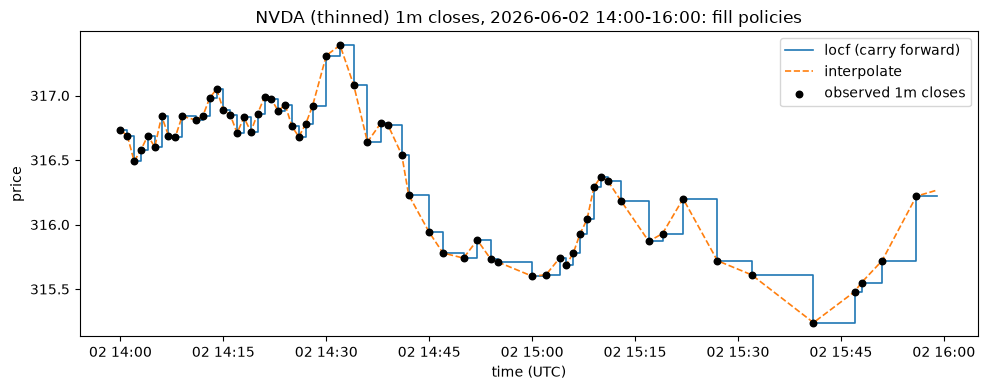

In [6]:
window = {}
for mode in ("null", "locf", "interpolate"):
    window[mode] = db.sql(
        f"""
        SELECT ts, close FROM gapfill('bars_nvda_1m', 'ts', 60000000, '{mode}')
        WHERE ts >= '2026-06-02T14:00:00Z' AND ts < '2026-06-02T16:00:00Z'
        ORDER BY ts
        """
    ).to_pandas()

obs = window["null"].dropna(subset=["close"])
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(window["locf"]["ts"], window["locf"]["close"],
        drawstyle="steps-post", lw=1.2, label="locf (carry forward)")
ax.plot(window["interpolate"]["ts"], window["interpolate"]["close"],
        lw=1.2, ls="--", label="interpolate")
ax.scatter(obs["ts"], obs["close"], s=22, color="black", zorder=3,
           label="observed 1m closes")
ax.set_title("NVDA (thinned) 1m closes, 2026-06-02 14:00-16:00: fill policies")
ax.set_xlabel("time (UTC)")
ax.set_ylabel("price")
ax.legend()
fig.tight_layout()

Two of these are safe in different ways and one is dangerous. `'null'` keeps
the holes honest. `'locf'` is causal, using only past data, but goes stale.
`'interpolate'` **looks ahead**: each filled point uses the *next*
observation, so an interpolated series must never feed a backtest signal.

## 5. `resample` alias, and the row-count guard

`resample(...)` is an exact alias of `gapfill(...)`. Both refuse to generate
more than 1M rows, so a fat-finger step raises a `LimitError` instead of
silently materializing millions of rows. Below, 100ms over three days trips
that guard.

A dense continuous series shows the honest use: 72 hours of EURUSD ticks onto
a 1-second grid. `cu.make_fx_ticks` gives `ts`, `pair`, `bid` and `ask`, from
which we keep the mid.

In [7]:
fx = cu.make_fx_ticks(pairs=["EURUSD"], hours=72).to_pandas()
fx["mid"] = (fx["bid"] + fx["ask"]) / 2
print(f"{len(fx):,} EURUSD ticks over 72h")
fx.head()

216,000 EURUSD ticks over 72h


,ts,pair,bid,ask,mid
0,2026-06-01 00:00:00.573381+00:00,EURUSD,1.07994,1.07998,1.079960
1,2026-06-01 00:00:01.638006+00:00,EURUSD,1.08003,1.08012,1.080075
2,2026-06-01 00:00:02.222298+00:00,EURUSD,1.08002,1.08009,1.080055
3,2026-06-01 00:00:02.327791+00:00,EURUSD,1.08000,1.08010,1.080050
4,2026-06-01 00:00:03.672276+00:00,EURUSD,1.07992,1.07998,1.079950


In [8]:
fx_schema = pa.schema([ts_field, pa.field("mid", pa.float64())])
db.create_table("fx_mid", fx_schema, time_column="ts", sort_key=["ts"])
db.append("fx_mid", pa.Table.from_pandas(fx[["ts", "mid"]], preserve_index=False).cast(fx_schema))

grid_1s = db.sql(
    "SELECT count(*) AS n, count(mid) AS filled FROM resample('fx_mid', 'ts', 1000000, 'locf')"
).to_pandas()
print(f"1s grid: {grid_1s['n'][0]:,} rows from {len(fx):,} irregular ticks")

try:
    db.sql("SELECT count(*) FROM resample('fx_mid', 'ts', 100000, 'locf')")
except h5i_db.LimitError as e:
    print(f"100ms grid refused -> {type(e).__name__} [{e.code}]: {e}")

1s grid: 259,199 rows from 216,000 irregular ticks


100ms grid refused -> LimitError [limit_exceeded]: [limit_exceeded] Resources exhausted: gapfill would generate 2591989 rows (limit 1000000)


## 6. Phantom returns: why the fill mode is a modelling decision

Mark the illiquid book off the locf grid and your minute returns are mostly
zero. Stale prices masquerade as "no move".

Below we compute the same return series both ways, using intraday pairs only
and excluding the overnight gap.

In [9]:
def session_returns(df: pd.DataFrame) -> pd.Series:
    d = df.copy()
    mins = d["ts"].dt.hour * 60 + d["ts"].dt.minute
    d = d[(mins >= 13 * 60 + 30) & (mins < 20 * 60)]
    ret = np.log(d["close"]).diff()
    ret[d["ts"].dt.date != d["ts"].shift().dt.date] = np.nan  # drop overnight pair
    return ret.dropna()

null_grid = db.sql(
    "SELECT ts, close FROM gapfill('bars_nvda_1m', 'ts', 60000000, 'null') ORDER BY ts"
).to_pandas()

ann = np.sqrt(390 * 252)  # per-minute -> annualized
r_locf = session_returns(locf)
r_null = session_returns(null_grid)  # defined only where adjacent minutes both traded

for name, r in (("locf grid", r_locf), ("null grid", r_null)):
    print(f"{name}: {len(r):>5,} minute returns | {(r == 0).mean():>4.0%} exactly zero | "
          f"ann. vol {r.std() * ann:.1%} | excess kurtosis {r.kurtosis():.1f}")

locf grid: 1,945 minute returns |  47% exactly zero | ann. vol 14.5% | excess kurtosis 5.5
null grid:   683 minute returns |   3% exactly zero | ann. vol 15.0% | excess kurtosis 0.5


Note what locf does and does not distort.

Total variance is roughly conserved. A stale run collapses the true move into
one delayed jump, so headline realized vol barely shifts.

The *distribution* is mangled. Nearly half the minutes report exactly zero
move, and excess kurtosis explodes to around 5.5 against roughly 0.5. The locf
series is "nothing happened" punctuated by fictitious jumps, timed at the next
print rather than at the move.

Anything consuming minute returns inherits that artifact: short-horizon risk,
jump detection, cross-correlations against liquid names (the Epps effect). A
sane production pattern is to store observed bars, publish the `'null'` grid,
and make carry-forward an explicit, documented step at the point of use.

## Takeaways

- `gapfill('table', 'ts', step_us, mode)` and `resample(...)` turn a stored
  bar table into a regular grid in one call. The step is raw microseconds
  (1m = 60_000_000) and generation is capped at 1M rows, raising a
  `LimitError` rather than an OOM.
- It treats the table as one series, so store one bar table per instrument.
  That is a natural fit, since bar tables are cheap versioned tables here.
- `'locf'` is causal but goes stale, and carries *all* columns forward,
  volume included. `'interpolate'` looks ahead and must never feed a backtest.
  `'null'` keeps the holes honest.
- Phantom returns are measurable. On the locf grid about half the minutes show
  a zero return and kurtosis is roughly 10x the observed-pair series. Headline
  vol survives; everything sensitive to the return *path* does not.

In [10]:
db.close()